# Нелинейные модели против южной погоды

В этом проекте решается задача прогноза почасового спроса на аренду велосипедов для компании BikeSouth. Целевая переменная — `Rented Bike Count`, то есть количество арендованных велосипедов за конкретный час. Прогноз строится по погодным и календарным признакам: температуре, влажности, ветру, видимости, осадкам, сезону, праздникам, рабочему статусу проката и периоду суток.

Бизнес-смысл задачи — помочь компании точнее планировать распределение велосипедов между станциями. Ошибки прогноза приводят либо к дефициту велосипедов для клиентов, либо к простою лишнего парка. Поэтому важно не просто получить формально хорошую модель, а снизить абсолютную и среднеквадратичную ошибку относительно базового линейного решения.

В качестве baseline используется готовый пайплайн линейной регрессии. Далее качество улучшается с помощью нелинейных моделей: `DecisionTreeRegressor` и `KNeighborsRegressor`. Для подбора гиперпараметров применяется Optuna, а качество моделей сравнивается по кросс-валидации на обучающей выборке. Тестовая выборка используется только один раз — для финальной проверки выбранной модели.

Основные гипотезы:
- спрос зависит не только от температуры, но и от сочетания температуры, влажности, осадков и солнечной радиации;
- временной период суток и сезон могут сильно менять поведение пользователей;
- признаки осадков и доступности проката могут резко снижать спрос даже при комфортной температуре;
- нелинейные модели должны лучше линейной регрессии учитывать взаимодействия признаков и снижать RMSE, MAE при росте R².

План работы:
1. Загрузить train/test данные и готовый baseline-пайплайн линейной регрессии.
2. Оценить baseline по `MAE`, `RMSE` и `R²` на train и test.
3. Провести первичный анализ данных: типы признаков, пропуски, распределение целевой переменной и связи признаков с таргетом.
4. Создать дополнительные погодные признаки: наличие осадков, сильные осадки, заморозки, взаимодействия температуры с влажностью и солнечной радиацией.
5. Собрать preprocessing-пайплайн с импутацией, масштабированием числовых признаков и кодированием категориального признака `seasons`.
6. Обучить базовые нелинейные модели `DecisionTreeRegressor` и `KNeighborsRegressor`.
7. Подобрать гиперпараметры моделей с помощью Optuna и сравнить результаты на кросс-валидации.
8. Проверить выбранную модель на тестовой выборке и сохранить итоговый пайплайн.

Основная метрика для оптимизации — `RMSE`, так как она сильнее штрафует крупные ошибки прогноза спроса. Дополнительно используются `MAE` для интерпретируемой средней ошибки в велосипедах и `R²` для оценки доли объяснённой вариативности.


In [1]:
import joblib

import numpy as np
import optuna
import pandas as pd
import phik
import seaborn as sns
from matplotlib import pyplot as plt
from optuna.visualization import plot_optimization_history
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import mutual_info_regression
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_validate, cross_val_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeRegressor

In [2]:
rs = 42

In [3]:
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
plt.rcParams["figure.figsize"] = (10, 5)
sns.set_theme(style="whitegrid")

In [4]:
try:
    df_train = pd.read_csv('ds_s14_train_data.csv')
    df_test = pd.read_csv('ds_s14_test_data.csv')

except FileNotFoundError as e:
    print(f"Локально файлы не найдены, идем в интернет")
    df_train = pd.read_csv('https://code.s3.yandex.net/datasets/ds_s14_train_data.csv')
    df_test = pd.read_csv('https://code.s3.yandex.net/datasets/ds_s14_test_data.csv')
data = {
    'train ': df_train,
    'test': df_test,
}

for name, df in data.items():
    print('=' * 70)
    print(f'{name}: {df.shape}')
    print('=' * 70)

train : (7008, 16)
test: (1752, 16)


In [5]:
for name, df in data.items():
    print(f"{'=' * 10} {name} {'=' * 10}")
    display(pd.concat([df.head(), df.tail(), df.sample(5)]))

========== train  ==========


,Temperature,Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature,Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day,Time_Period_Evening,Time_Period_Late Evening,Time_Period_Morning,Time_Period_Night,Rented Bike Count
0,20.3,35.0,2.4,2000.0,4.3,0.46,0.0,0.0,Autumn,Holiday,Yes,True,False,False,False,1237
1,25.4,55.0,3.2,2000.0,15.6,0.15,0.0,0.0,Autumn,No Holiday,Yes,True,False,False,False,2468
2,-6.9,39.0,1.6,2000.0,-18.5,0.00,0.0,0.0,Winter,No Holiday,Yes,False,True,False,False,186
3,-5.2,37.0,2.2,2000.0,-17.6,0.00,0.0,0.0,Winter,No Holiday,Yes,False,False,False,True,254
4,23.4,34.0,2.1,2000.0,6.6,2.84,0.0,0.0,Autumn,No Holiday,Yes,False,False,False,False,1686
7003,-4.2,40.0,0.9,1216.0,-15.8,0.00,0.0,0.0,Winter,No Holiday,Yes,True,False,False,False,410
7004,2.9,51.0,0.8,1119.0,-6.2,0.00,0.0,0.0,Spring,No Holiday,Yes,False,False,False,True,163
7005,5.3,73.0,0.7,2000.0,0.8,0.01,0.0,0.0,Autumn,No Holiday,Yes,False,False,True,False,1142
7006,4.4,64.0,1.4,2000.0,-1.8,0.00,0.0,0.0,Autumn,No Holiday,Yes,False,False,False,True,362
7007,16.3,40.0,0.8,1982.0,2.6,0.25,0.0,0.0,Spring,No Holiday,Yes,False,False,True,False,429


========== test ==========


,Temperature,Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature,Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day,Time_Period_Evening,Time_Period_Late Evening,Time_Period_Morning,Time_Period_Night,Rented Bike Count
0,6.7,48.0,0.8,817.0,-3.5,0.39,0.0,0.0,Winter,No Holiday,Yes,False,False,False,False,402
1,-5.3,90.0,1.1,311.0,-6.6,0.00,0.0,2.2,Winter,No Holiday,Yes,False,False,True,False,178
2,2.9,66.0,1.2,173.0,-2.8,0.00,0.0,0.0,Winter,No Holiday,Yes,False,True,False,False,219
3,23.1,63.0,2.6,949.0,15.6,1.68,0.0,0.0,Spring,No Holiday,Yes,False,False,False,False,949
4,23.3,43.0,1.2,1257.0,10.0,1.91,0.0,0.0,Summer,No Holiday,Yes,False,False,True,False,1005
1747,4.9,84.0,1.3,159.0,2.4,0.00,0.1,0.0,Winter,Holiday,Yes,False,False,True,False,12
1748,28.9,64.0,1.7,1567.0,21.3,0.10,0.0,0.0,Summer,No Holiday,Yes,False,True,False,False,2174
1749,2.0,87.0,1.9,140.0,0.0,0.03,0.0,0.0,Winter,No Holiday,Yes,True,False,False,False,18
1750,5.9,65.0,1.0,596.0,-0.1,0.00,0.0,0.0,Spring,No Holiday,Yes,False,False,False,True,231
1751,17.1,51.0,2.5,1223.0,6.8,NaN,0.0,0.0,Spring,No Holiday,Yes,True,False,False,False,1999


In [6]:
for name, df in data.items():
    print(f"{'=' * 10} {name} {'=' * 10}")
    df.info()

========== train  ==========
<class 'pandas.DataFrame'>
RangeIndex: 7008 entries, 0 to 7007
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Temperature               7008 non-null   float64
 1   Humidity(%)               6758 non-null   float64
 2   Wind speed (m/s)          6798 non-null   float64
 3   Visibility (10m)          6749 non-null   float64
 4   Dew point temperature     7008 non-null   float64
 5   Solar Radiation (MJ/m2)   6798 non-null   float64
 6   Rainfall(mm)              6746 non-null   float64
 7   Snowfall (cm)             6745 non-null   float64
 8   Seasons                   7008 non-null   str    
 9   Holiday                   7008 non-null   str    
 10  Functioning Day           7008 non-null   str    
 11  Time_Period_Evening       7008 non-null   bool   
 12  Time_Period_Late Evening  7008 non-null   bool   
 13  Time_Period_Morning       7008 non-null   boo

In [7]:
X_train = df_train.drop(columns='Rented Bike Count')
y_train = df_train['Rented Bike Count']
X_test = df_test.drop(columns='Rented Bike Count')
y_test = df_test['Rented Bike Count']

## бейзлайн линрег

In [8]:
def evaluate_holdout_model(model, model_name, X_train, y_train, X_test, y_test):
    rows = []
    for split_name, X, y in [
        ('train', X_train, y_train),
        ('test', X_test, y_test),
    ]:
        y_pred = model.predict(X)
        rows.append({
            'model': model_name,
            'dataset': split_name,
            'mae_mean': mean_absolute_error(y, y_pred),
            'rmse_mean': root_mean_squared_error(y, y_pred),
            'r2_mean': r2_score(y, y_pred),
        })

    return pd.DataFrame(rows).set_index(['model', 'dataset'])

loaded_linreg = joblib.load('baseline_linear_regression_pipeline.pkl')
baseline_scores = evaluate_holdout_model(
    loaded_linreg,
    model_name='baseline',
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
)
display(baseline_scores)

scores = baseline_scores.xs('test', level='dataset').copy()

mae_mean   rmse_mean   r2_mean
model    dataset                                  
baseline train    309.078381  412.526355  0.592544
         test     312.599334  411.564089  0.586072

Метрики baseline на `train` и `test` близки, но сами ошибки остаются высокими. Существенного переобучения нет, однако качества линейной модели недостаточно.


In [9]:
for df in [df_train, df_test]:
    df.columns = (
        df.columns
        .str.lower()
        .str.strip()
        .str.replace(" ", "_")
        .str.replace(r"[()%/]", "", regex=True)
    )

In [10]:
features = df_train.drop(columns="rented_bike_count").columns
target = df_train["rented_bike_count"]

## фьюче инженеринг

In [11]:
df_train_rezerv = df_train.copy()
df_test_rezerv = df_test.copy()

In [12]:
rainfall_95 = df_train["rainfallmm"].quantile(0.95)
snowfall_95 = df_train["snowfall_cm"].quantile(0.95)

binary_columns = [
    "time_period_evening",
    "time_period_late_evening",
    "time_period_morning",
    "time_period_night"
]

for df in [df_train, df_test]:
    df["freezing"] = (df["temperature"] < 0).astype(int)
    df["windy"] = (df["wind_speed_ms"] > 3.3).astype(int)
    df["good_visibility"] = (df["visibility_10m"] > 500).astype(int)

    df["has_rain"] = (df["rainfallmm"] > 0).astype(int)
    df["has_snow"] = (df["snowfall_cm"] > 0).astype(int)
    df["has_precipitation"] = ((df["has_rain"] == 1) | (df["has_snow"] == 1)).astype(int)

    df["heavy_rain"] = (df["rainfallmm"] > rainfall_95).astype(int)
    df["heavy_snow"] = (df["snowfall_cm"] > snowfall_95).astype(int)
    df["bad_precipitation"] = ((df["heavy_rain"] == 1) | (df["heavy_snow"] == 1)).astype(int)

    df["temp_humidity"] = df["temperature"] * df["humidity"]
    df["solar_temp"] = df["solar_radiation_mjm2"] * df["temperature"]
    df["comfort_temp_gap"] = df["temperature"] - df["dew_point_temperature"]

    df["holiday"] = df["holiday"].replace({
        "No Holiday": 0,
        "Holiday": 1
    }).astype(int)

    df["functioning_day"] = df["functioning_day"].replace({
        "Yes": 1,
        "No": 0
    }).astype(int)

    for col in binary_columns:
        df[col] = df[col].astype(int)

## пропуски

In [13]:
summary_train = pd.DataFrame({
        'column': df_train.columns,
        'dtype': df_train.dtypes.values,
        'nunique': df_train.nunique().values,
        'missing': df_train.isna().sum().values,
        'missing_share': (df_train.isna().mean().values).round(3)
    })
summary_test = pd.DataFrame({
        'column': df_test.columns,
        'dtype': df_test.dtypes.values,
        'nunique': df_test.nunique().values,
        'missing': df_test.isna().sum().values,
        'missing_share': (df_test.isna().mean().values).round(3)
    })

display(summary_train)
display(summary_test)

,column,dtype,nunique,missing,missing_share
0,temperature,float64,541,0,0.000
1,humidity,float64,87,250,0.036
2,wind_speed_ms,float64,64,210,0.030
3,visibility_10m,float64,1697,259,0.037
4,dew_point_temperature,float64,547,0,0.000
5,solar_radiation_mjm2,float64,344,210,0.030
6,rainfallmm,float64,53,262,0.037
7,snowfall_cm,float64,47,263,0.038
8,seasons,str,4,0,0.000
9,holiday,int64,2,0,0.000


,column,dtype,nunique,missing,missing_share
0,temperature,float64,470,0,0.000
1,humidity,float64,88,72,0.041
2,wind_speed_ms,float64,54,52,0.030
3,visibility_10m,float64,850,72,0.041
4,dew_point_temperature,float64,490,0,0.000
5,solar_radiation_mjm2,float64,287,52,0.030
6,rainfallmm,float64,29,64,0.037
7,snowfall_cm,float64,30,61,0.035
8,seasons,str,4,0,0.000
9,holiday,int64,2,0,0.000


Пропуски сосредоточены в погодных признаках и не превышают примерно 4%. Это позволяет ограничиться импутацией внутри пайплайна.


## распределения

In [14]:
def graphics_numerical(df, column):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.histplot(df[column], kde=True, ax=axes[0])
    axes[0].set_title(f'Распределение признака: {column}')
    axes[0].set_xlabel('Значения')
    axes[0].set_ylabel('Количество')

    sns.boxplot(x=df[column], ax=axes[1])
    axes[1].set_title(f'Boxplot: {column}')
    axes[1].set_xlabel('Значения')
    axes[1].set_ylabel('Количество')

    plt.tight_layout()
    plt.show()

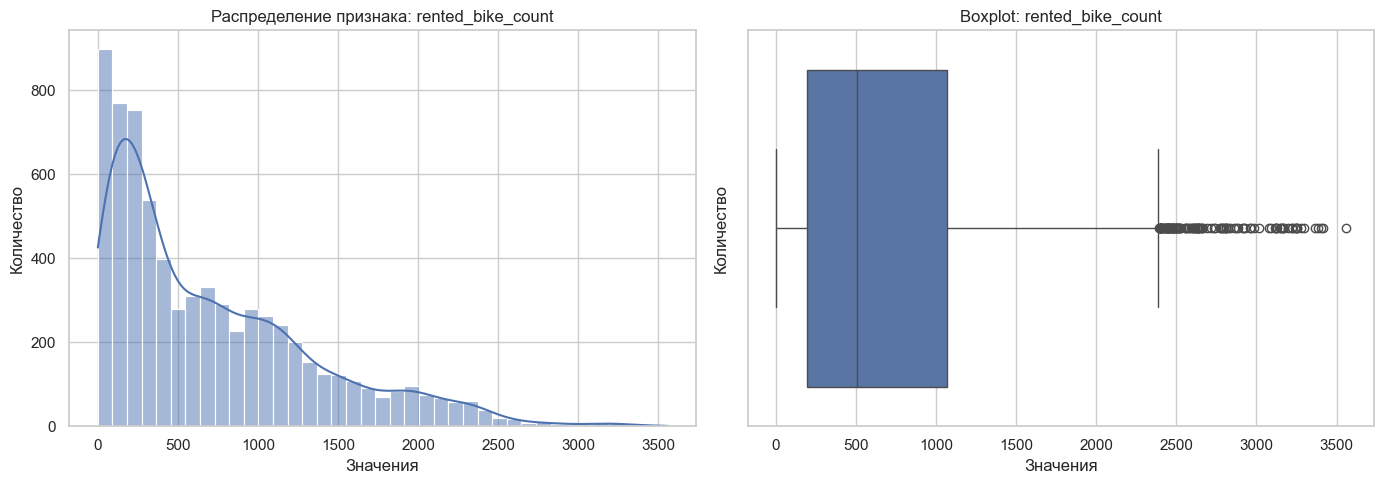

In [15]:
graphics_numerical(df_train, 'rented_bike_count')

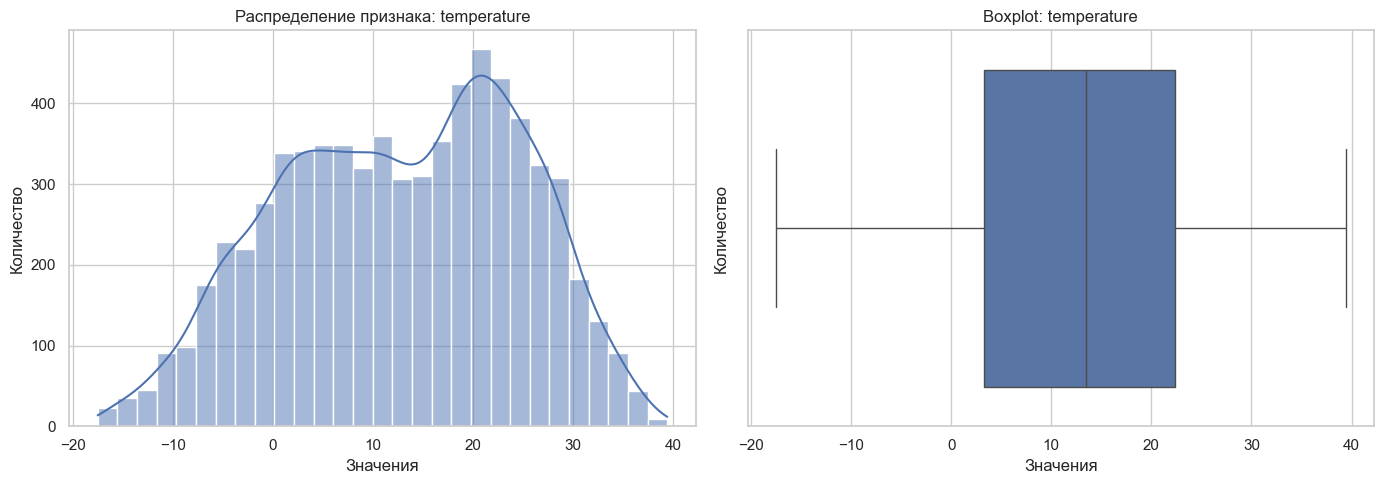

In [39]:
graphics_numerical(df_train, 'temperature')

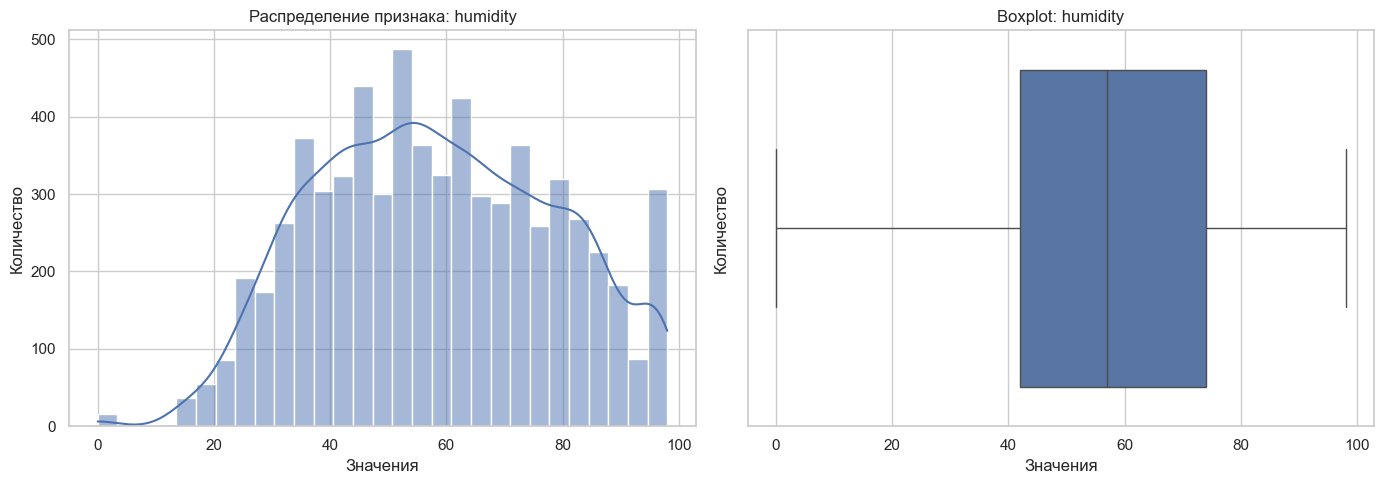

In [40]:
graphics_numerical(df_train, 'humidity')

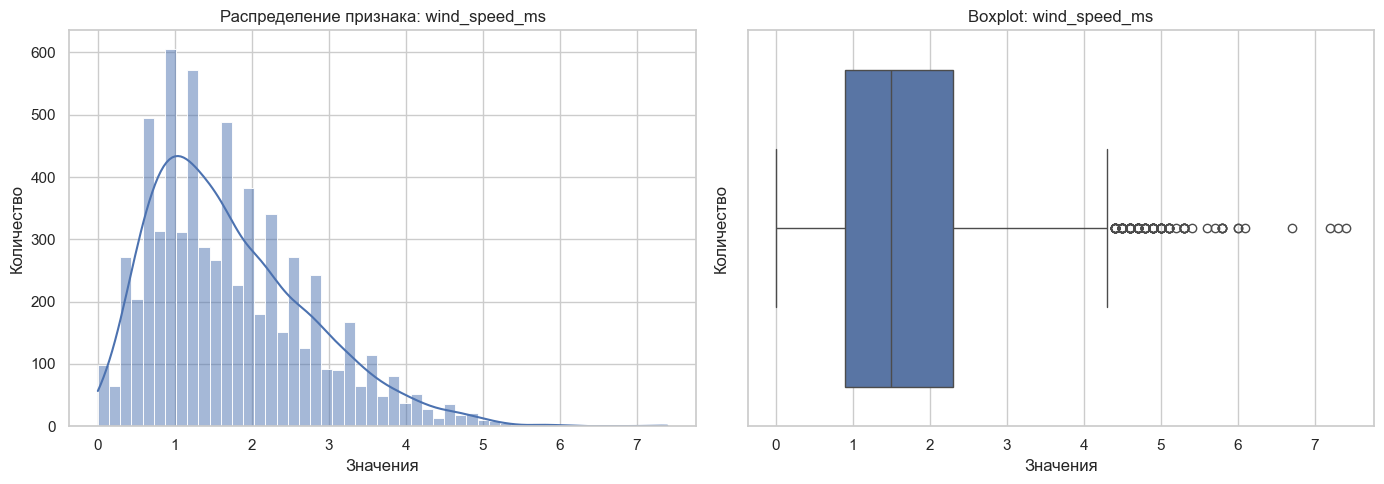

In [41]:
graphics_numerical(df_train, 'wind_speed_ms')

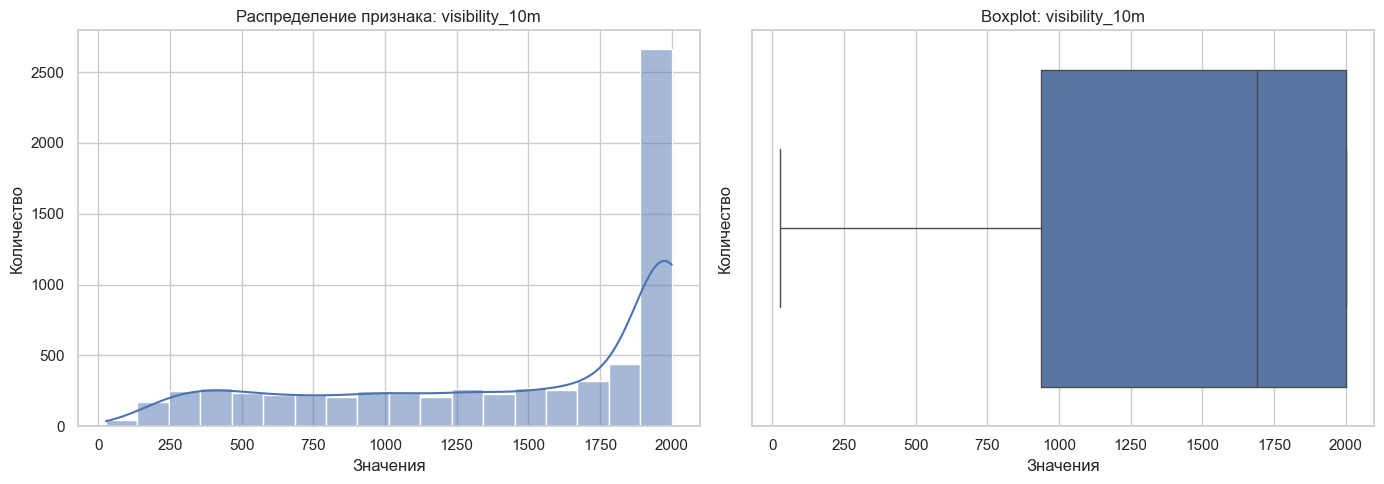

In [42]:
graphics_numerical(df_train, 'visibility_10m')

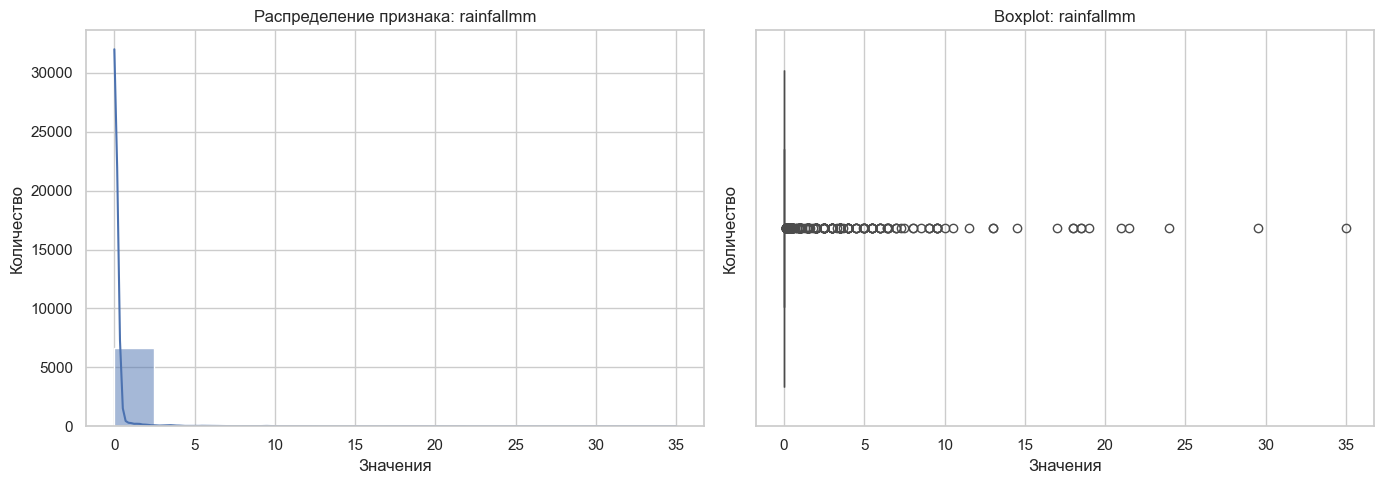

In [43]:
graphics_numerical(df_train, 'rainfallmm')

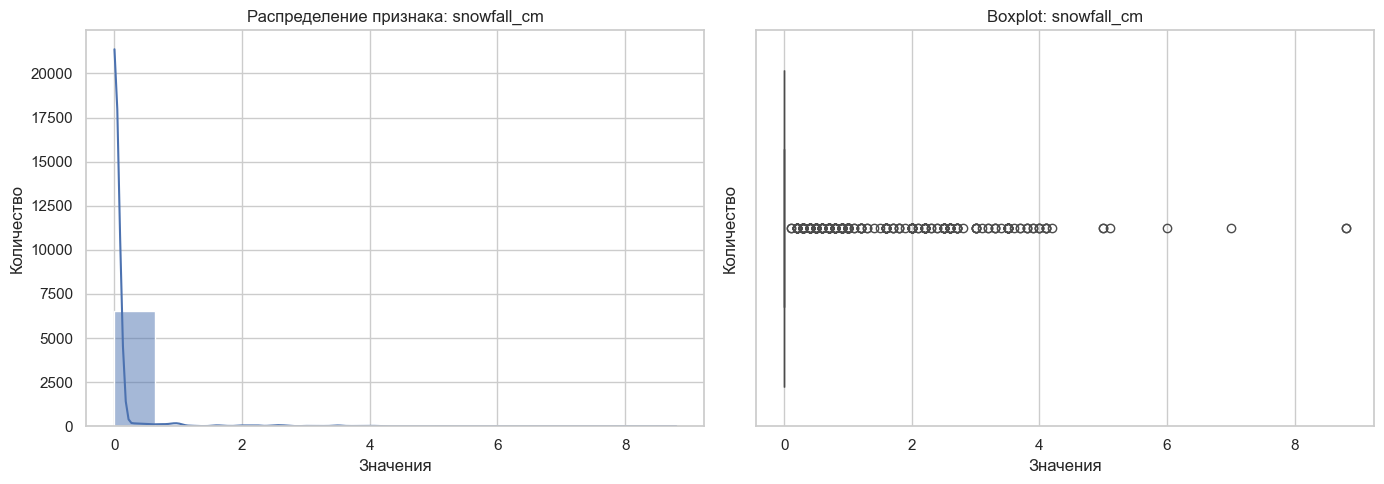

In [44]:
graphics_numerical(df_train, 'snowfall_cm')

По распределениям видно, что целевая переменная скошена вправо: большинство часов имеют умеренный спрос, но встречаются пики с очень большим количеством аренд. Температура и влажность распределены относительно ровно, поэтому их можно использовать как основные погодные признаки без дополнительной ручной группировки.

Осадки ведут себя иначе: `rainfallmm` и `snowfall_cm` почти всегда равны нулю, но имеют редкие крупные значения. Поэтому для модели полезны не только исходные числовые значения осадков, но и бинарные признаки факта дождя/снега и сильных осадков. По boxplot также видны выбросы в погодных признаках

In [17]:
X_train = df_train.drop('rented_bike_count', axis=1)
y_train = df_train['rented_bike_count']

X_test = df_test.drop(columns="rented_bike_count")
y_test = df_test['rented_bike_count']

## коллеарность

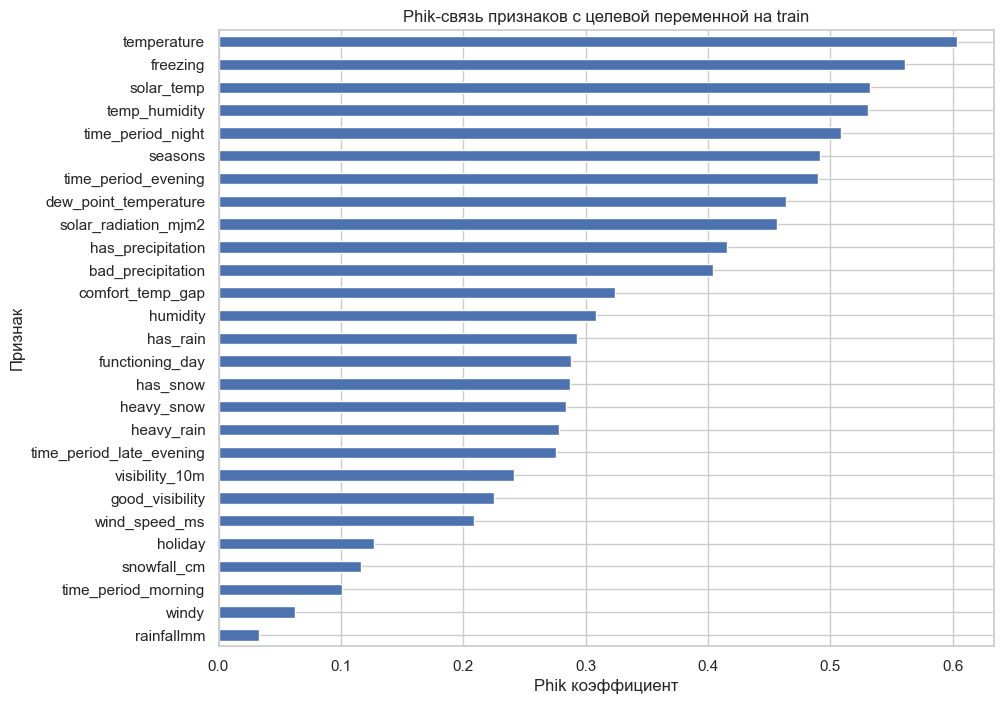

temperature                 0.603136
freezing                    0.560908
solar_temp                  0.532327
temp_humidity               0.531008
time_period_night           0.508885
seasons                     0.491204
time_period_evening         0.489551
dew_point_temperature       0.463809
solar_radiation_mjm2        0.456615
has_precipitation           0.415304
bad_precipitation           0.403946
comfort_temp_gap            0.323839
humidity                    0.308656
has_rain                    0.293290
functioning_day             0.288384
has_snow                    0.287594
heavy_snow                  0.284100
heavy_rain                  0.278115
time_period_late_evening    0.275677
visibility_10m              0.241367
good_visibility             0.224735
wind_speed_ms               0.208813
holiday                     0.126826
snowfall_cm                 0.116801
time_period_morning         0.101005
windy                       0.062511
rainfallmm                  0.032741
N

In [18]:
target_col = "rented_bike_count"

binary_cols = [
    "holiday",
    "functioning_day",
    "time_period_evening",
    "time_period_late_evening",
    "time_period_morning",
    "time_period_night",
    "freezing",
    "windy",
    "good_visibility",
    "has_rain",
    "has_snow",
    "has_precipitation",
    "heavy_rain",
    "heavy_snow",
    "bad_precipitation",
]

phik_data = df_train.copy()

interval_cols = [
    col for col in phik_data.select_dtypes(include="number").columns
    if col not in binary_cols
]

phik_corr = phik_data.phik_matrix(interval_cols=interval_cols)

target_phik = (
    phik_corr[target_col]
    .drop(target_col)
    .sort_values(ascending=False)
)

target_phik.sort_values().plot(kind="barh", figsize=(10, 8))
plt.title("Phik-связь признаков с целевой переменной на train")
plt.xlabel("Phik коэффициент")
plt.ylabel("Признак")
plt.show()

display(target_phik)

Выраженнее всего с целевой переменной связаны температура, её производные и временные признаки. `windy` и `rainfallmm` выглядят слабыми и частично дублируются более информативными переменными.


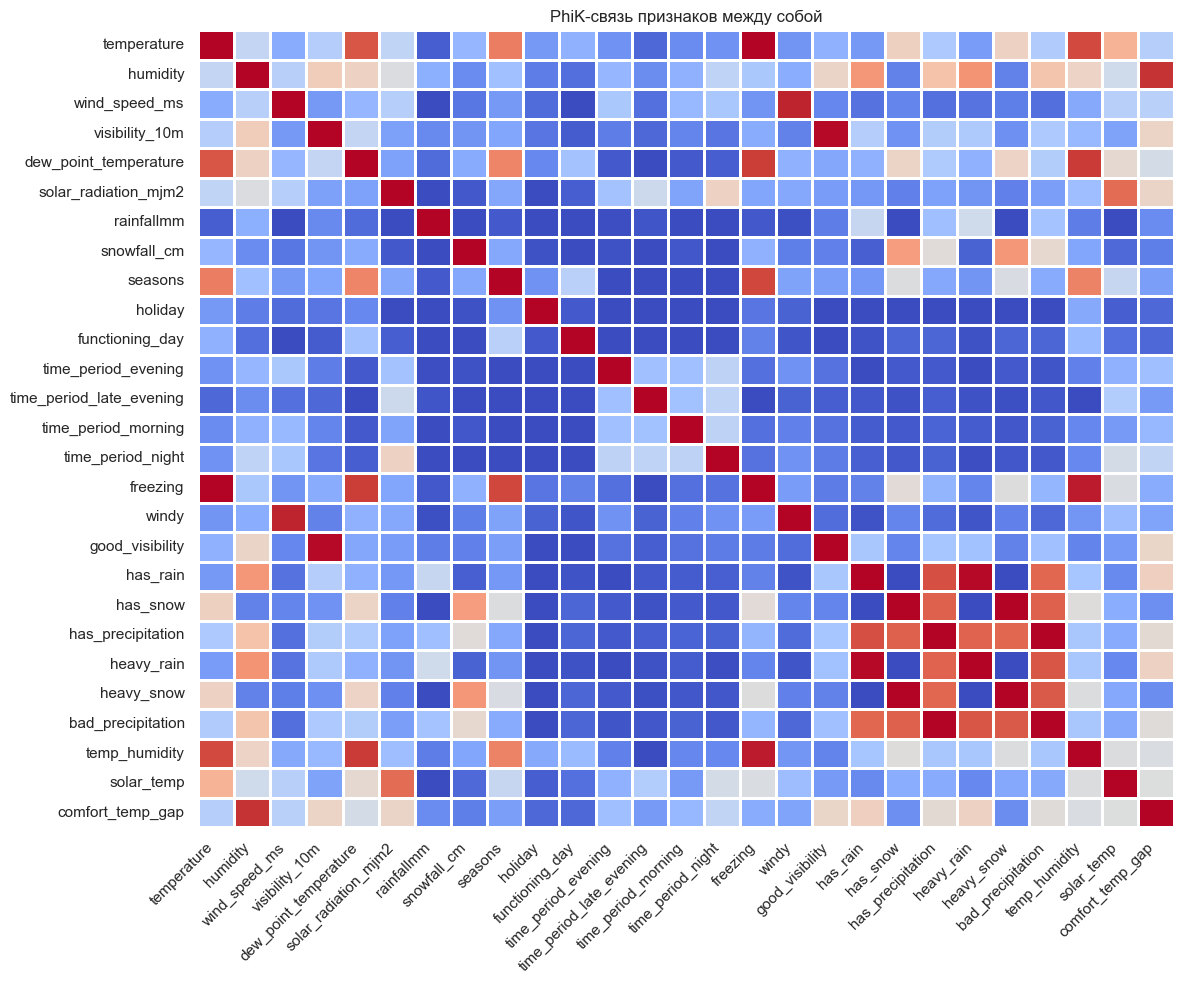

In [19]:
phik_features = phik_corr.drop(
    index=target_col,
    columns=target_col
)

plt.figure(figsize=(12, 10))

sns.heatmap(
    phik_features,
    cmap="coolwarm",
    linewidths=1.0,
    cbar=False
)

plt.title("PhiK-связь признаков между собой")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


In [20]:
num_cols = X_train.select_dtypes(include='number').columns.tolist()
cat_cols = ['seasons']
target = ['rented_bike_count']

In [21]:
num_cols = X_train.select_dtypes(include='number').columns.tolist()
cat_cols = ['seasons']

In [22]:
num_X = X_train.select_dtypes(include='number')
imputer = SimpleImputer(strategy='median')
X_imputed = pd.DataFrame(imputer.fit_transform(num_X), columns=num_X.columns)

mi_scores = mutual_info_regression(X_imputed, y_train, random_state=42)
mi_scores = pd.Series(mi_scores, index=X_imputed.columns).sort_values(ascending=False)

In [23]:
display(mi_scores)

temperature                 0.380494
temp_humidity               0.279752
solar_temp                  0.279239
dew_point_temperature       0.238515
solar_radiation_mjm2        0.185695
functioning_day             0.144800
freezing                    0.135202
comfort_temp_gap            0.129565
time_period_night           0.113761
has_precipitation           0.093408
humidity                    0.089618
bad_precipitation           0.084327
time_period_evening         0.062808
rainfallmm                  0.060624
has_rain                    0.057230
snowfall_cm                 0.055643
heavy_rain                  0.052965
heavy_snow                  0.051407
visibility_10m              0.049592
has_snow                    0.046227
good_visibility             0.026954
time_period_late_evening    0.021217
wind_speed_ms               0.019499
windy                       0.011895
time_period_morning         0.007966
holiday                     0.000000
dtype: float64

`mutual_info` подтверждает тот же сигнал: основную информацию дают температура, её производные и часть погодных индикаторов. `holiday` и часть бинарных признаков почти не влияют на прогноз.


In [24]:
cols_to_drop = ['windy', 'rainfallmm', 'good_visibility']

X_train = X_train.drop(columns=cols_to_drop)
X_test = X_test.drop(columns=cols_to_drop)

num_cols = [col for col in num_cols if col not in cols_to_drop]

In [25]:
cv = KFold(n_splits=5, shuffle=True, random_state=rs)
num_pipe = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipe = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_pipe, num_cols),
        ('cat', cat_pipe, cat_cols)
    ],
    remainder='drop'
)

In [26]:
scoring = {
    'neg_mae': 'neg_mean_absolute_error',
    'neg_rmse': 'neg_mean_squared_error',
    'r2': 'r2'
}

def evaluate_model(model, model_name):
    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    cv_result = cross_validate(
        pipe, X_train, y_train,
        cv=cv, scoring=scoring, n_jobs=-1
    )

    scores.loc[model_name] = [
        -cv_result['test_neg_mae'].mean(),
        np.sqrt(-cv_result['test_neg_rmse'].mean()),
        cv_result['test_r2'].mean(),
    ]

    pipe.fit(X_train, y_train)

    scores_df = scores.sort_values(by='rmse_mean', ascending=True)
    display(scores_df.round(4))

    return pipe, cv_result

In [27]:
knn_pipe, knn_baseline = evaluate_model(KNeighborsRegressor(n_neighbors=3, n_jobs=-1), model_name="KNeighborsRegressor")

,mae_mean,rmse_mean,r2_mean
model,,,
KNeighborsRegressor,209.7560,324.0652,0.7484
baseline,312.5993,411.5641,0.5861


In [28]:
decision_tree_pipe, decision_tree_cv = evaluate_model(
    DecisionTreeRegressor(max_depth=5, random_state=rs),
    model_name='DecisionTreeRegressor'
)

,mae_mean,rmse_mean,r2_mean
model,,,
KNeighborsRegressor,209.7560,324.0652,0.7484
DecisionTreeRegressor,262.7925,379.3085,0.6554
baseline,312.5993,411.5641,0.5861


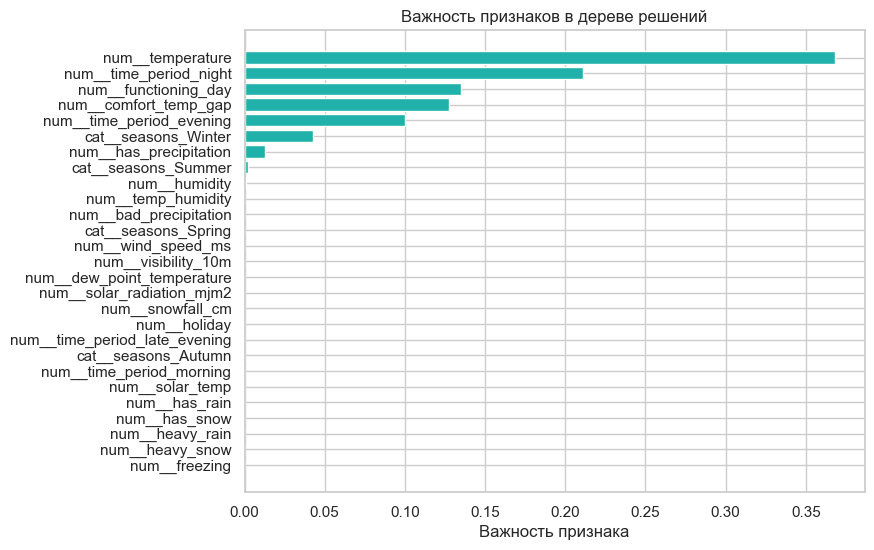

In [29]:
feature_names = preprocessor.get_feature_names_out()

importances = pd.Series(
    decision_tree_pipe.named_steps['model'].feature_importances_,
    index=feature_names
).sort_values()

plt.figure(figsize=(8, 6))
plt.barh(importances.index, importances.values, color='lightseagreen')
plt.xlabel('Важность признака')
plt.title('Важность признаков в дереве решений')
plt.show()

По дереву решений видно, что модель в первую очередь опирается на температуру, ночной период, доступность проката и производные температурные признаки.


In [30]:
def objective(trial):
    params = {
        "max_depth": trial.suggest_int("max_depth", 3, 30),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 50),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 30),
        "criterion": trial.suggest_categorical(
            "criterion",
            ["squared_error", "friedman_mse", "absolute_error"]
        ),
    }

    model = DecisionTreeRegressor(random_state=42, **params)

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    scores = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=3,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1
    )

    mean_rmse = -scores.mean()

    trial.report(mean_rmse, step=0)

    if trial.should_prune():
        raise optuna.TrialPruned()

    return mean_rmse

In [31]:
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=50)
print("Лучшие параметры дерева:", study.best_params)
print("Лучший RMSE на CV:", study.best_value)

[I 2026-05-21 13:02:57,225] A new study created in memory with name: no-name-d7ff9cbc-377b-4908-ac47-c56dd0227803
[I 2026-05-21 13:02:57,523] Trial 0 finished with value: 320.0599557934573 and parameters: {'max_depth': 28, 'min_samples_split': 26, 'min_samples_leaf': 16, 'criterion': 'friedman_mse'}. Best is trial 0 with value: 320.0599557934573.
[I 2026-05-21 13:02:57,588] Trial 1 finished with value: 326.2882626187513 and parameters: {'max_depth': 19, 'min_samples_split': 28, 'min_samples_leaf': 9, 'criterion': 'squared_error'}. Best is trial 0 with value: 320.0599557934573.
[I 2026-05-21 13:02:58,479] Trial 2 finished with value: 334.8210462542194 and parameters: {'max_depth': 12, 'min_samples_split': 48, 'min_samples_leaf': 30, 'criterion': 'absolute_error'}. Best is trial 0 with value: 320.0599557934573.
[I 2026-05-21 13:02:58,532] Trial 3 finished with value: 328.9074766351614 and parameters: {'max_depth': 20, 'min_samples_split': 33, 'min_samples_leaf': 23, 'criterion': 'friedma

Лучшие параметры дерева: {'max_depth': 26, 'min_samples_split': 32, 'min_samples_leaf': 13, 'criterion': 'friedman_mse'}
Лучший RMSE на CV: 319.0028777815382


In [32]:
fig = plot_optimization_history(study)
fig.show()

Optuna быстро нашла хорошую область параметров: уже к 10-20 trial значение RMSE снизилось примерно с 320+ до 319. После этого улучшения почти прекратились, линия лучшего значения вышла на плато. Значит, 50 trials было достаточно для подбора дерева, но дальнейшее увеличение числа попыток вряд ли сильно улучшит качество.

In [33]:
best_tree = DecisionTreeRegressor(
    random_state=rs,
    **study.best_params
)

best_tree_pipe, best_tree_cv = evaluate_model(
    best_tree,
    model_name="DecisionTreeRegressor_Optuna"
)

,mae_mean,rmse_mean,r2_mean
model,,,
KNeighborsRegressor,209.7560,324.0652,0.7484
DecisionTreeRegressor_Optuna,213.3255,324.8960,0.7471
DecisionTreeRegressor,262.7925,379.3085,0.6554
baseline,312.5993,411.5641,0.5861


Optuna заметно улучшила дерево решений относительно базовой версии: `RMSE` снизился с `379.31` до `319.80`, `R²` вырос с `0.6554` до `0.7550`.


In [34]:
def objective_knn(trial):
    params = {
        "n_neighbors": trial.suggest_int("n_neighbors", 2, 50),
        "weights": trial.suggest_categorical("weights", ["uniform", "distance"]),
        "p": trial.suggest_int("p", 1, 2),
    }

    model = KNeighborsRegressor(**params, n_jobs=-1)

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    scores = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=3,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1
    )

    mean_rmse = -scores.mean()

    trial.report(mean_rmse, step=0)

    if trial.should_prune():
        raise optuna.TrialPruned()

    return mean_rmse

In [35]:
study_knn = optuna.create_study(direction="minimize")
study_knn.optimize(objective_knn, n_trials=50)

print("Лучшие параметры kNN:", study_knn.best_params)
print("Лучший RMSE:", study_knn.best_value)

[I 2026-05-21 13:03:07,880] A new study created in memory with name: no-name-899b2335-bde2-433b-a3f8-86ceb93f1b03
[I 2026-05-21 13:03:08,157] Trial 0 finished with value: 316.48496599663537 and parameters: {'n_neighbors': 3, 'weights': 'distance', 'p': 1}. Best is trial 0 with value: 316.48496599663537.
[I 2026-05-21 13:03:08,299] Trial 1 finished with value: 313.78165575393956 and parameters: {'n_neighbors': 18, 'weights': 'uniform', 'p': 2}. Best is trial 1 with value: 313.78165575393956.
[I 2026-05-21 13:03:08,397] Trial 2 finished with value: 313.10951597812374 and parameters: {'n_neighbors': 5, 'weights': 'uniform', 'p': 2}. Best is trial 2 with value: 313.10951597812374.
[I 2026-05-21 13:03:08,487] Trial 3 finished with value: 317.3233775988981 and parameters: {'n_neighbors': 45, 'weights': 'distance', 'p': 2}. Best is trial 2 with value: 313.10951597812374.
[I 2026-05-21 13:03:08,564] Trial 4 finished with value: 305.900943954164 and parameters: {'n_neighbors': 17, 'weights': 'd

Лучшие параметры kNN: {'n_neighbors': 11, 'weights': 'distance', 'p': 1}
Лучший RMSE: 295.7964382622697


In [36]:
fig = plot_optimization_history(study_knn)
fig.show()

Для kNN Optuna дала более заметный выигрыш: RMSE постепенно снизился примерно с 316 до 296. Основное улучшение произошло в первой половине поиска, примерно до 25 trial, после чего лучшее значение почти не менялось.

In [37]:
best_knn = KNeighborsRegressor(
    **study_knn.best_params
)

best_knn_pipe, best_knn_cv = evaluate_model(
    best_knn,
    model_name="KNN_optuna"
)

,mae_mean,rmse_mean,r2_mean
model,,,
KNN_optuna,195.7887,296.3819,0.7895
KNeighborsRegressor,209.7560,324.0652,0.7484
DecisionTreeRegressor_Optuna,213.3255,324.8960,0.7471
DecisionTreeRegressor,262.7925,379.3085,0.6554
baseline,312.5993,411.5641,0.5861


После подбора гиперпараметров `KNN_optuna` стал лучшей моделью на кросс-валидации. Он обошёл и baseline, и обе версии дерева решений.


**Шаг 5. Кросс-валидация новых моделей**

После кросс-валидации видно, что обе оптимизированные модели лучше baseline. `DecisionTreeRegressor_Optuna` заметно улучшил дерево, но лучший результат показал `KNN_optuna`: `RMSE = 296.38`, `MAE = 195.79`, `R² = 0.7895`.


In [38]:
final_model = best_knn_pipe

y_pred_test = final_model.predict(X_test)

final_test_scores = pd.DataFrame({
    'mae': [mean_absolute_error(y_test, y_pred_test)],
    'rmse': [root_mean_squared_error(y_test, y_pred_test)],
    'r2': [r2_score(y_test, y_pred_test)]
}, index=['KNN_Optuna_test'])

display(final_test_scores.round(4))

joblib.dump(final_model, 'final_knn_optuna_pipeline.pkl')

,mae,rmse,r2
KNN_Optuna_test,193.9797,288.4567,0.7967


['final_knn_optuna_pipeline.pkl']


Лучше всего с прогнозом справился `KNN_optuna`. Он даёт минимальные ошибки и максимальный `R²` среди всех протестированных моделей.

Для дерева решений наиболее важными оказались `temperature`, `time_period_night`, `functioning_day`, `comfort_temp_gap` и `time_period_evening`. В целом это подтверждает, что спрос определяется не одним погодным фактором, а сочетанием температуры, времени суток и доступности проката.


Итоговое сравнение показывает устойчивое преимущество оптимизированного kNN над baseline, обычным kNN и деревом решений. Базовый линейный пайплайн не улавливает нелинейные зависимости в данных, тогда как kNN лучше реагирует на сочетания погодных и календарных условий. Для бизнес-задачи это означает более точный прогноз спроса и меньше ошибок в распределении велосипедов по станциям.


**Шаг 7. Сохранение модели и отчёта**

Финальной моделью выбран `KNN_optuna`, так как он показал лучшее качество на кросс-валидации и сохранил это преимущество на тестовой выборке.


На тестовой выборке финальная модель получила `MAE = 193.98`, `RMSE = 288.46`, `R² = 0.7967`. Пайплайн сохранён в файл `final_knn_optuna_pipeline.pkl`.
